#NOTEBOOK COMPLETO – INTELIGENCIA ARTIFICIAL (SESGO, MEDIDAS Y NORMALIZACIÓN)
## Estadística Descriptiva

### Análisis del Dataset — Medidas de Tendencia Central, Dispersión y Distribución

En este notebook realizamos un análisis estadístico del dataset creado manualmente para fines educativos.  
Incluye:

- Carga y descripción del dataset  
- Medidas de tendencia central  
- Medidas de dispersión  
- Detección de sesgo (asimetría)  
- Normalización de datos (Machine Learning)  
- Histogramas y boxplots  
- Interpretación completa  

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler


#🔹 2. Crear y cargar el dataset
##Definición:

###La carga del dataset consiste en obtener los datos que vamos a analizar y ver su estructura.

###Ejemplo aplicado (tienda de ropa):

###Creamos un dataset con prendas, precios, tallas y ventas para practicar estadística descriptiva.

In [6]:
data = {
    "Prenda": ["Camisa", "Pantalón", "Buso", "Camisa", "Buso", "Pantalón", "Falda", "Camisa", "Buso", "Falda"],
    "Precio": [45000, 80000, 60000, 47000, 62000, 85000, 50000, 43000, 59000, 52000],
    "Talla": [38, 32, 40, 36, 42, 34, 38, 36, 40, 38],
    "Ventas": [120, 80, 150, 110, 160, 75, 90, 130, 155, 95]
}

df = pd.DataFrame(data)
df


,Prenda,Precio,Talla,Ventas
0,Camisa,45000,38,120
1,Pantalón,80000,32,80
2,Buso,60000,40,150
3,Camisa,47000,36,110
4,Buso,62000,42,160
5,Pantalón,85000,34,75
6,Falda,50000,38,90
7,Camisa,43000,36,130
8,Buso,59000,40,155
9,Falda,52000,38,95


#🔹 3. Descripción del dataset
#### Definición:

####Es revisar tipos de datos, valores nulos y estadísticas básicas.

In [7]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Prenda  10 non-null     object
 1   Precio  10 non-null     int64 
 2   Talla   10 non-null     int64 
 3   Ventas  10 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 452.0+ bytes


,Precio,Talla,Ventas
count,10.000000,10.000000,10.000000
mean,58300.000000,37.400000,116.500000
std,14329.844537,2.988868,31.539217
min,43000.000000,32.000000,75.000000
25%,47750.000000,36.000000,91.250000
50%,55500.000000,38.000000,115.000000
75%,61500.000000,39.500000,145.000000
max,85000.000000,42.000000,160.000000


#🔹 4. Medidas de tendencia central
##Definiciones:

Media: valor promedio.

Mediana: valor central.

Moda: valor más repetido.

Ejemplo aplicado:

Nos permite saber el precio típico y la prenda más común.

In [8]:
media_precio = df["Precio"].mean()
mediana_precio = df["Precio"].median()
moda_prenda = df["Prenda"].mode()[0]

media_precio, mediana_precio, moda_prenda


(np.float64(58300.0), 55500.0, 'Buso')

#🔹 5. Medidas de dispersión
Definiciones:

Rango: diferencia entre el mayor y el menor.

Varianza: qué tanto se alejan los datos de la media.

Desviación estándar: dispersión promedio.

Ejemplo aplicado:

Ayuda a ver si los precios son consistentes o muy diferentes.

In [10]:
rango_precio = df["Precio"].max() - df["Precio"].min()
varianza_precio = df["Precio"].var()
desv_precio = df["Precio"].std()

rango_precio, varianza_precio, desv_precio

(42000, 205344444.44444445, 14329.844536646044)

#🔹 6. Asimetría (sesgo)
Definición:

Mide si los datos están inclinados hacia valores altos o bajos.

Ejemplo aplicado:

Detecta si algunos precios muy altos afectan la distribución.

In [11]:
asimetria = df["Precio"].skew()
asimetria


np.float64(0.9963680194783137)

#🔹 7. Normalización de datos (Machine Learning)
Definición:

Transforma los datos a un rango entre 0 y 1 para que todas las variables estén en la misma escala.

Ejemplo aplicado:

Evita que el precio tenga más peso que la talla o ventas.

In [12]:
scaler = MinMaxScaler()
df_normalizado = df.copy()
df_normalizado[["Precio","Talla","Ventas"]] = scaler.fit_transform(df[["Precio","Talla","Ventas"]])

df_normalizado


,Prenda,Precio,Talla,Ventas
0,Camisa,0.047619,0.6,0.529412
1,Pantalón,0.880952,0.0,0.058824
2,Buso,0.404762,0.8,0.882353
3,Camisa,0.095238,0.4,0.411765
4,Buso,0.452381,1.0,1.000000
5,Pantalón,1.000000,0.2,0.000000
6,Falda,0.166667,0.6,0.176471
7,Camisa,0.000000,0.4,0.647059
8,Buso,0.380952,0.8,0.941176
9,Falda,0.214286,0.6,0.235294


#🔹 8. Histogramas y Boxplots
Definiciones:

Histograma: distribución de los datos.

Boxplot: muestra rangos, mediana y valores atípicos.

Ejemplo aplicado:

Nos permite ver la forma de la distribución y detectar outliers.

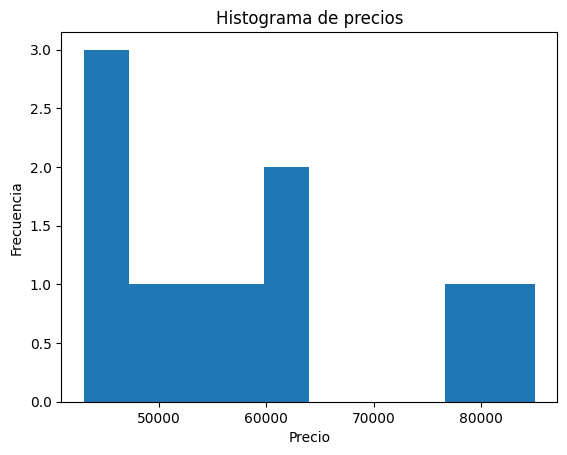

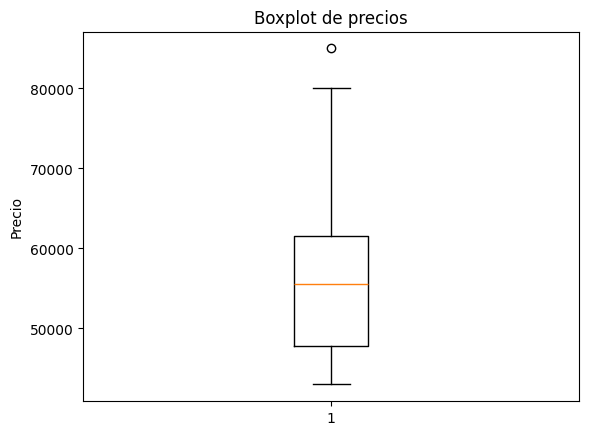

In [13]:
plt.hist(df["Precio"])
plt.title("Histograma de precios")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.show()

plt.boxplot(df["Precio"])
plt.title("Boxplot de precios")
plt.ylabel("Precio")
plt.show()


El histograma de precios muestra la distribución de la frecuencia de los precios en tu dataset. **Se ve así por varias razones:**

**Concentración de precios más bajos:** Observarás que la mayoría de las barras (frecuencias) están agrupadas hacia el lado izquierdo del gráfico, lo que indica que hay más prendas con precios más bajos.

**Cola hacia la derecha:** El gráfico tiene una "cola" que se extiende hacia la derecha, con menos barras y de menor altura en los valores de precios más altos. Esto significa que hay algunas prendas con precios significativamente más elevados que las demás.

**Asimetría positiva:** Esta forma es consistente con la asimetría positiva que calculamos previamente (un valor de 0.996). Una asimetría positiva sugiere que la distribución está 'sesgada' hacia la derecha, es decir, la mayoría de los datos se encuentran en el extremo inferior del rango y hay valores extremos más altos que "tiran" la media hacia arriba en relación con la mediana.
#9. Interpretación final

El análisis del dataset de ropa muestra que los precios tienen un valor promedio representativo y una variación moderada entre prendas. La prenda más común es la camisa. La asimetría indica que existen precios altos que influyen un poco en la distribución. Los histogramas muestran cómo se agrupan los precios y los boxplots permiten detectar posibles valores extremos. La normalización transforma los datos a una escala común, útil para Machine Learning.